In [3]:
from google.colab import files

uploaded = files.upload()


Saving test_catvnoncat.h5 to test_catvnoncat.h5
Saving train_catvnoncat.h5 to train_catvnoncat.h5


In [4]:
# Task 3: Modified train/test split using only the original training set

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import h5py
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Same preprocessing pipeline as before
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


Using device: cpu


In [5]:
# Load only the original training set from train_catvnoncat.h5
with h5py.File("train_catvnoncat.h5", "r") as f:
    train_x_full = np.array(f["train_set_x"])    # (209, 64, 64, 3)
    train_y_full = np.array(f["train_set_y"])    # (209,)

print("Original training images:", train_x_full.shape)
print("Original training labels:", train_y_full.shape)

# New split for Task 3
# First 160 + (0) = first 160 images for new training set
# Remaining 49 images for new test set
n_train_new = 160
train_x_new = train_x_full[:n_train_new]
train_y_new = train_y_full[:n_train_new]

test_x_new  = train_x_full[n_train_new:]
test_y_new  = train_y_full[n_train_new:]

print("New train images:", train_x_new.shape, " New train labels:", train_y_new.shape)
print("New test  images:", test_x_new.shape,  " New test  labels:", test_y_new.shape)


Original training images: (209, 64, 64, 3)
Original training labels: (209,)
New train images: (160, 64, 64, 3)  New train labels: (160,)
New test  images: (49, 64, 64, 3)  New test  labels: (49,)


In [6]:
class CatDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.uint8)
        label = self.labels[idx]

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(label, dtype=torch.float32)
        return img, label


# Use the new split
train_dataset = CatDataset(train_x_new, train_y_new, transform=transform)
test_dataset  = CatDataset(test_x_new,  test_y_new,  transform=transform)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [7]:
# Build the model (same structure as Task 1)

model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)   # binary classification

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

num_epochs = 8


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


In [8]:
# Train the model on the NEW training set

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total_train += images.size(0)

    avg_loss = running_loss / total_train
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")


Epoch [1/8], Loss: 0.7839
Epoch [2/8], Loss: 0.6135
Epoch [3/8], Loss: 0.4660
Epoch [4/8], Loss: 0.3728
Epoch [5/8], Loss: 0.3126
Epoch [6/8], Loss: 0.2168
Epoch [7/8], Loss: 0.1946
Epoch [8/8], Loss: 0.1693


In [9]:
# Evaluate on the NEW train and test sets

model.eval()
train_preds_all, train_labels_all = [], []
test_preds_all,  test_labels_all  = [], []
misclassified_indices = []   # indices in the NEW test set (0 to 48)
idx = 0

with torch.no_grad():
    # New training set
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        train_preds_all.extend(preds.cpu().numpy().flatten())
        train_labels_all.extend(labels.cpu().numpy().flatten())

    # New test set
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        preds_np  = preds.cpu().numpy().flatten()
        labels_np = labels.cpu().numpy().flatten()

        # store for accuracy
        test_preds_all.extend(preds_np)
        test_labels_all.extend(labels_np)

        # record misclassified indices (0-based in NEW test set)
        batch_size = labels_np.shape[0]
        for i in range(batch_size):
            if preds_np[i] != labels_np[i]:
                misclassified_indices.append(idx + i)
        idx += batch_size

train_preds_all = np.array(train_preds_all)
train_labels_all = np.array(train_labels_all)
test_preds_all  = np.array(test_preds_all)
test_labels_all = np.array(test_labels_all)

train_acc_new = np.mean(train_preds_all == train_labels_all)
test_acc_new  = np.mean(test_preds_all  == test_labels_all)

print(f"New Training Accuracy: {train_acc_new:.2f}")
print(f"New Testing Accuracy:  {test_acc_new:.2f}")
print("Misclassified indices in NEW test set (0-based):", misclassified_indices)


New Training Accuracy: 1.00
New Testing Accuracy:  0.94
Misclassified indices in NEW test set (0-based): [5, 25, 47]


Showing up to 4 misclassified images from the new test set...



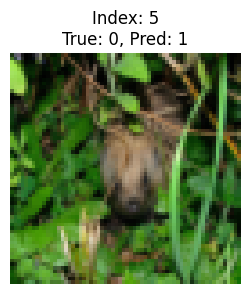

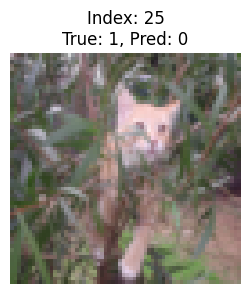

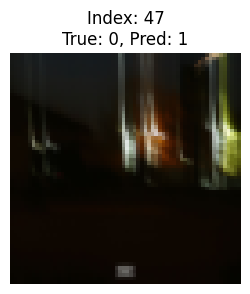

In [10]:
# Display up to 4 misclassified images from the NEW test set

if len(misclassified_indices) == 0:
    print("No misclassified images in the new test set.")
else:
    print("Showing up to 4 misclassified images from the new test set...\n")

    num_to_show = min(4, len(misclassified_indices))
    for k in range(num_to_show):
        idx = misclassified_indices[k]       # index inside NEW test set (0 to 48)
        img = test_x_new[idx]                # raw image from new test set
        true_label = test_y_new[idx]
        pred_label = int(test_preds_all[idx])

        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.title(f"Index: {idx}\nTrue: {true_label}, Pred: {pred_label}")
        plt.axis("off")
        plt.show()
